In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datasets.loader import load_splits
from datasets.paths import ProjectPaths
from nltk.tokenize import ToktokTokenizer
from config.settings import Settings
import string


In [2]:
settings = Settings()
print(settings)


batch_size=64 mlp_dropout=0.4 lstm_dropout=0.3 pooling='mean' similarity='mlp' hidden_dim=64 bidirectional=False mlp_layers=[32] concat_features=['diff'] embedding_trainable=False epochs=20 augmented_data=False siamese_name='lstm_mean_mlp' max_len=26 augmented_max_len=26 case=False strip_punctuation=True


In [3]:
paths = ProjectPaths()

In [4]:
splits = {
	"train": paths.processed_dir,
	"dev": paths.processed_dir,
	"test": paths.processed_dir
}

dfs = load_splits(splits)
df = pd.concat(dfs.values(), ignore_index=True)


In [5]:
for split, df_split in dfs.items():
    print(f"{split}: {len(df_split)}")
    

train: 5741
dev: 1497
test: 1377


In [17]:
df.columns


Index(['sentence1', 'sentence2', 'score', 'split', 'score_norm'], dtype='str')

In [18]:
df["split"].unique()


<StringArray>
['train', 'dev', 'test']
Length: 3, dtype: str

In [19]:
df.describe()


,score,score_norm
count,8615.000000,8615.000000
mean,2.627489,0.525498
std,1.485648,0.297130
min,0.000000,0.000000
25%,1.400000,0.280000
50%,2.800000,0.560000
75%,3.800000,0.760000
max,5.000000,1.000000


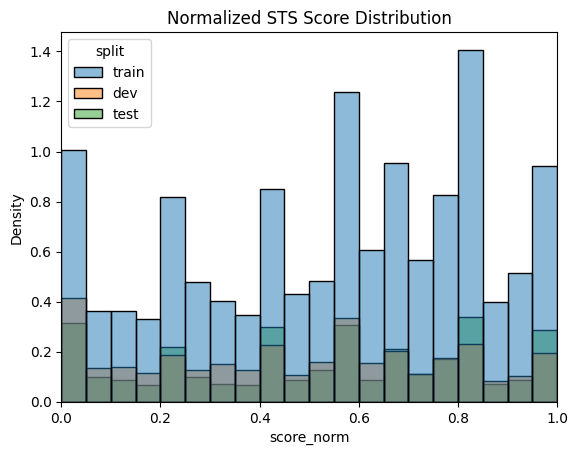

In [20]:
sns.histplot(df, x="score_norm", hue="split", bins=20, stat="density")
plt.title("Normalized STS Score Distribution")
plt.xlim(0,1)
plt.show()


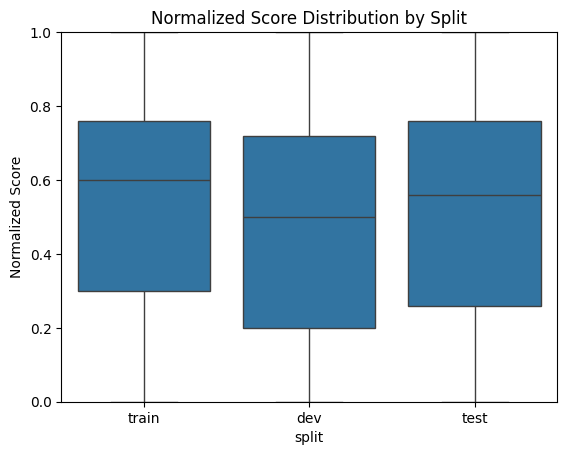

In [21]:
sns.boxplot(data=df, x="split", y="score_norm")

plt.title("Normalized Score Distribution by Split")
plt.ylabel("Normalized Score")
plt.ylim(0, 1)
plt.show()

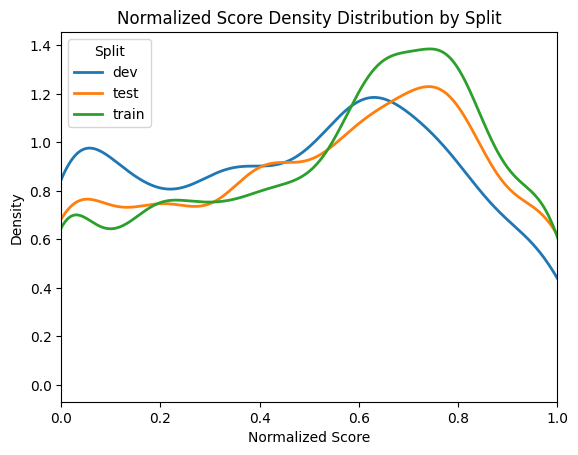

In [22]:
for split, data in df.groupby("split"):
	data["score_norm"].plot(kind="kde", label=split, linewidth=2)

plt.xlabel("Normalized Score")
plt.ylabel("Density")
plt.title("Normalized Score Density Distribution by Split")
plt.xlim(0, 1)
plt.legend(title="Split")
plt.show()

In [23]:
tokenizer = ToktokTokenizer()

def remove_punctuation(text: str):
    # translate(...) -> aplicar una tabla para reemplazar unos caracteres por otros
    # maketrans(x, y, z)) -> crear una tabla de traducción (x: caracteres que se reemplazan, y: caracteres nuevos que los sustituyen, z: caracteres que eliminar)
    return text.translate(str.maketrans("", "", string.punctuation))

def preprocess(text):
    if settings.strip_punctuation:
        text = remove_punctuation(text)
    return text

df["len1"] = df["sentence1"].apply(
    lambda x: len(tokenizer.tokenize(preprocess(x)))
)

df["len2"] = df["sentence2"].apply(
    lambda x: len(tokenizer.tokenize(preprocess(x)))
)

df[["len1", "len2"]].describe()


,len1,len2
count,8615.000000,8615.000000
mean,12.103308,12.044689
std,6.578702,6.444165
min,2.000000,2.000000
25%,8.000000,7.000000
50%,10.000000,10.000000
75%,15.000000,14.000000
max,77.000000,58.000000


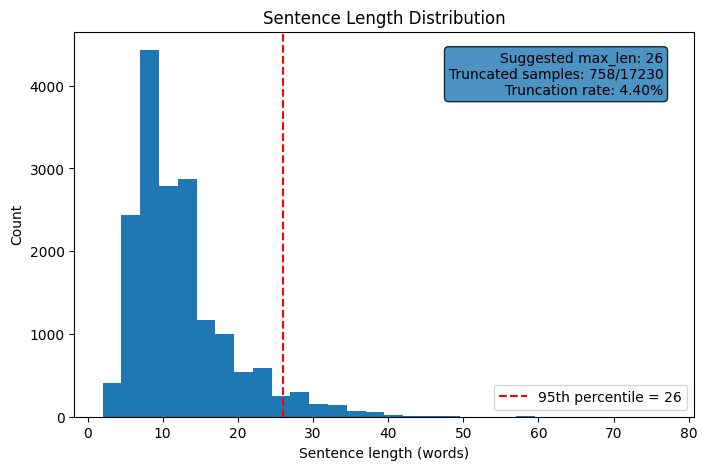

In [24]:
all_lengths = np.concatenate([df["len1"].values, df["len2"].values])

# Percentil 95 como max_len recomendado
max_len = int(np.percentile(all_lengths, 95))

# Tasa de truncamiento
truncated = (df["len1"] > max_len).sum() + (df["len2"] > max_len).sum()
total = len(df) * 2
truncation_rate = truncated / total

# Histograma
plt.figure(figsize=(8, 5))

plt.hist(all_lengths, bins=30)

# Línea del percentil 95
plt.axvline(
    max_len,
    color="red",
    linestyle="--",
    label=f"95th percentile = {max_len}"
)

info = (
    f"Suggested max_len: {max_len}\n"
    f"Truncated samples: {truncated}/{total}\n"
    f"Truncation rate: {truncation_rate:.2%}"
)

plt.text(
    0.95,
    0.95,
    info,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round", alpha=0.8)
)

plt.xlabel("Sentence length (words)")
plt.ylabel("Count")
plt.title("Sentence Length Distribution")
plt.legend()
plt.show()
